# Aufgabe 1


## CAL3

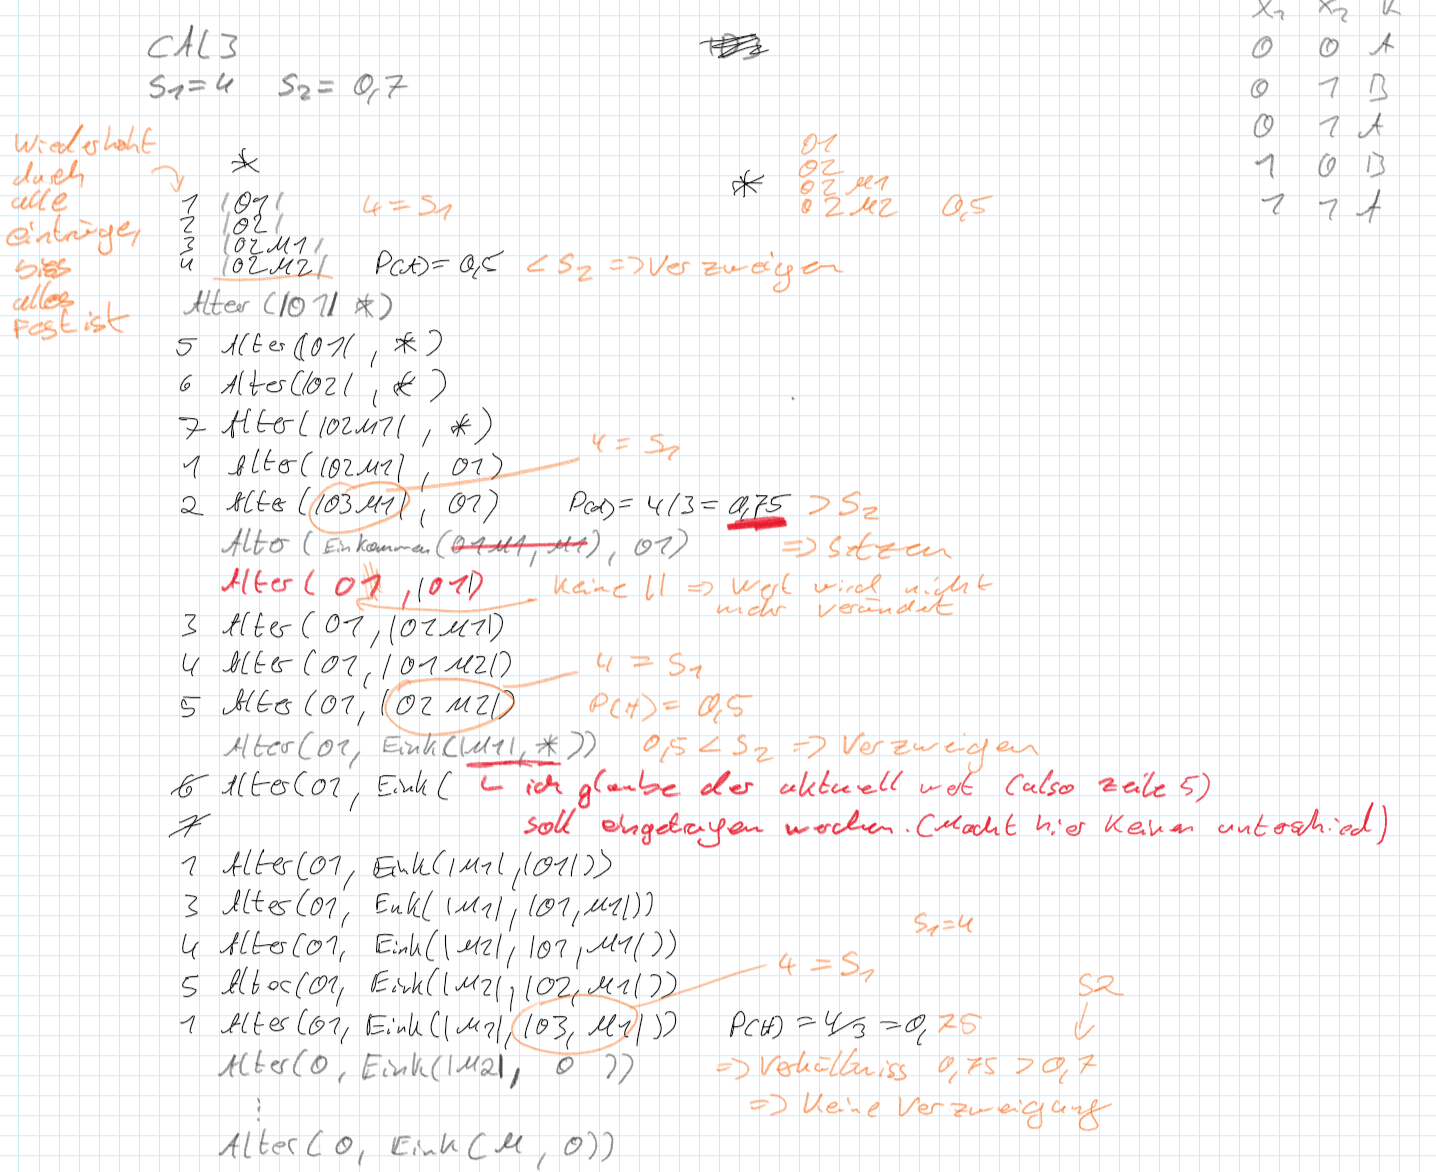

## ID3

In [1]:

double CalculateHeuristic(IEnumerable<int> classes) {

    var c = classes.ToArray();
    double length = c.Length;
    double tmp = 0;

    foreach (var g in  c.GroupBy(x => x)) {
        double count = g.Count();
        var t = (count / length) * Math.Log2(count / length);
        tmp += t;
    }
    return -tmp;
}

double CalculateEntropy(IEnumerable<(int Attribute, int Class)> values) 
{
    var v = values.ToArray();
    double length = v.Length;
    double tmp = 0;

    foreach (var group in v.GroupBy(x => x.Attribute)) {
        var groupValues = group.ToArray();
        double groupLength = groupValues.Length;

        tmp += (groupLength / length) * CalculateHeuristic(groupValues.Select(x => x.Class));
    }

    return tmp;
}

double CalculateGain(IEnumerable<(int Attribute, int Class)> values) {
    var v = values.ToArray();
    return CalculateHeuristic(v.Select(x => x.Class)) - CalculateEntropy(v);
}

In [2]:
CalculateHeuristic([0,0,1,1,0,0,1])

0.9852281360342515

In [3]:
// Example: x1
CalculateEntropy([(0, 0), (1, 0), (0, 0), (1, 1), (0, 1), (0, 0)])

0.8741854163060885

In [ ]:
// Alter:   0 => < 35
// Eink:    0 => niedrig
// Bildung: 0 => Abi, 1 => Bachelor
const int O = 0;
const int M = 1;


// CalculateEntropy -> use lowest
// CalculateGain -> use highest
Console.WriteLine("Alter: {0:0.00}", CalculateEntropy([(1, O), (0, O), (1, M), (1, M), (1, O), (0, O), (0, M)]));
Console.WriteLine("Einko: {0:0.00}", CalculateEntropy([(1, O), (0, O), (1, M), (0, M), (1, O), (1, O), (0, M)]));
Console.WriteLine("Bildu: {0:0.00}", CalculateEntropy([(0, O), (2, O), (1, M), (0, M), (2, O), (1, O), (0, M)]));

Alter: 0.96
Einko: 0.86
Bildu: 0.68


In [52]:
stateDiagram-v2

b1: {1,4,7}, {A, E}, M
b2: {3, 6}, {A, E}, ?
b3: {2, 5}, {A, E}, O

Bildung --> b1 : Abitur
Bildung --> b2 : Bachelor
Bildung --> b3 : Master

In [44]:
Console.WriteLine("A Alter: {0:0.00}", CalculateGain([(1, O), (1, M), (0, M)])); //1,4,7
Console.WriteLine("A Einko: {0:0.00}", CalculateGain([(1, O), (0, M), (0, M)]));

Console.WriteLine("B Alter: {0:0.00}", CalculateGain([(1, M), (0, O)])); // 3, 6
Console.WriteLine("B Einko: {0:0.00}", CalculateGain([(1, M), (1, O)])); // 3, 6

Console.WriteLine("M Alter: {0:0.00}", CalculateGain([(0, O), (1, O)])); // 2, 5
Console.WriteLine("M Einko: {0:0.00}", CalculateGain([(0, O), (1, O)])); // 2, 5

A Alter: 0.25
A Einko: 0.92
B Alter: 1.00
B Einko: 0.00
M Alter: -0.00
M Einko: -0.00


**Branch Abitur**
Einkommen hat höhere aussagekraft als Alter

**Branch Bachelor**
Einkommen hat keine aussagekraft (beide gleich)
Alter "perfekte" aussagekraft

**Branch Master**
Keine aussagekraft (bereits eindeutig) | Alle haben die gleiche klasse -> Entscheidung

In [54]:
stateDiagram-v2

b1: {1,4,7}, {A, E}, M
b2: {3, 6}, {A, E}, ?
b3: O

Bildung --> b1 : Abitur
Bildung --> b2 : Bachelor
Bildung --> b3 : Master

e11: {4,7}, {E}, M
e12: {1} {A}, O 
b1 --> e11 : niedrig
b1 --> e12 : hoch

a21: {6}, {A}, O
a22: {3}, {A}, M
b2 --> a21 : < 35
b2 --> a22 : >= 35


In [55]:
Console.WriteLine("AN Alter: {0:0.00}", CalculateGain([(1, M), (0, M)])); //4,7
Console.WriteLine("AH Alter: {0:0.00}", CalculateGain([(1, O)])); //1

Console.WriteLine("BS Einko: {0:0.00}", CalculateGain([(1, O)])); // 6
Console.WriteLine("BL Einko: {0:0.00}", CalculateGain([(1, M)])); // 3

AN Alter: -0.00
AH Alter: -0.00
BS Einko: -0.00
BL Einko: -0.00


Keine Aussagekraft mehr. (Alle Gruppen haben die gleiche Klasse bzw sind alleine)


In [1]:
stateDiagram-v2

b1: {1,4,7}, {A, E}, M
b2: {3, 6}, {A, E}, ?
b3: O

Bildung --> b1 : Abitur
Bildung --> b2 : Bachelor
Bildung --> b3 : Master

e11: M
e12: O 
b1 --> e11 : niedrig
b1 --> e12 : hoch

a21: O
a22: M
b2 --> a21 : < 35
b2 --> a22 : >= 35


# Aufgabe 2

```
x3 ( 
    x2 ( 
        x1 ( C , A ), 
        x1 ( B , A ) 
    ) , 
    x1 ( 
        x2 ( C , B ), 
        A 
    )
) 
```



*Manuel*
```
x3 ( 
    x1 (
        x2 ( C, B ),
        A
    ), 
    x1 ( 
        x2 ( C , B ), 
        A 
    )
) 
```
```
x1 ( 
    x2 ( C , B ), 
    A 
)
```

# Aufgabe 3

## Zoo

```
J48 pruned tree
------------------
x3 <= 0
|   x5 <= 0
|   |   x10 <= 0
|   |   |   x6 <= 0
|   |   |   |   x8 <= 0
|   |   |   |   |   x14 <= 2: shellfish (2.0)
|   |   |   |   |   x14 > 2: insect (2.0)
|   |   |   |   x8 > 0: shellfish (8.0)
|   |   |   x6 > 0: insect (6.0)
|   |   x10 > 0
|   |   |   x13 <= 0
|   |   |   |   x15 <= 0: amphibian (3.0)
|   |   |   |   x15 > 0: reptile (6.0/1.0)
|   |   |   x13 > 0: fish (13.0)
|   x5 > 0: mammal (41.0)
x3 > 0: bird (20.0) 

=== Confusion Matrix ===

  a  b  c  d  e  f  g   <-- classified as
 41  0  0  0  0  0  0 |  a = mammal
  0 13  0  0  0  0  0 |  b = fish
  0  0 20  0  0  0  0 |  c = bird
  0  0  0 10  0  0  0 |  d = shellfish
  0  0  0  0  8  0  0 |  e = insect
  0  0  0  0  0  3  1 |  f = amphibian
  0  0  0  0  0  0  5 |  g = reptile
```

![alt text](image.png)


## Restaurant

**Note:**
Additional whitespaces where removed.
column 9 was moved to the back to 


```

J48 pruned tree
------------------

 x2 =  No
|    x6 =  $$$:  French (2.0)
|    x6 =  $:  Thai (3.0)
|    x6 =  $$:  Thai (1.0)
 x2 =  Yes
|    x8 =  Yes:  Italian (2.0)
|    x8 =  No:  Burger (4.0)


=== Confusion Matrix ===

 a b c d   <-- classified as
 2 0 0 0 | a =  French
 0 4 0 0 | b =  Thai
 0 0 4 0 | c =  Burger
 0 0 0 2 | d =  Italian

```


## ARFF Attributes

 * Nominal: List of possible values "Enum"
 * ~~Ordinal:~~
 * Numeric: number. Can also be integer or real
 * String: arbitrary text


*Der ID3 kann nur Nominal Werte handhaben*

*Note: the first attribute (name) was removed* 

## Zoo

```
J48 pruned tree
------------------
x3 <= 0
|   x5 <= 0
|   |   x10 <= 0
|   |   |   x6 <= 0
|   |   |   |   x8 <= 0
|   |   |   |   |   x14 <= 2: shellfish (2.0)
|   |   |   |   |   x14 > 2: insect (2.0)
|   |   |   |   x8 > 0: shellfish (8.0)
|   |   |   x6 > 0: insect (6.0)
|   |   x10 > 0
|   |   |   x13 <= 0
|   |   |   |   x15 <= 0: amphibian (3.0)
|   |   |   |   x15 > 0: reptile (6.0/1.0)
|   |   |   x13 > 0: fish (13.0)
|   x5 > 0: mammal (41.0)
x3 > 0: bird (20.0)

=== Summary ===

Correctly Classified Instances         100               99.0099 %
Incorrectly Classified Instances         1                0.9901 %
Kappa statistic                          0.987 
Mean absolute error                      0.0047
Root mean squared error                  0.0486
Relative absolute error                  2.1552 %
Root relative squared error             14.7377 %
Total Number of Instances              101     

=== Detailed Accuracy By Class ===

                 TP Rate  FP Rate  Precision  Recall   F-Measure  MCC      ROC Area  PRC Area  Class
                 1,000    0,000    1,000      1,000    1,000      1,000    1,000     1,000     mammal
                 1,000    0,000    1,000      1,000    1,000      1,000    1,000     1,000     fish
                 1,000    0,000    1,000      1,000    1,000      1,000    1,000     1,000     bird
                 1,000    0,000    1,000      1,000    1,000      1,000    1,000     1,000     shellfish
                 1,000    0,000    1,000      1,000    1,000      1,000    1,000     1,000     insect
                 0,750    0,000    1,000      0,750    0,857      0,862    0,994     0,861     amphibian
                 1,000    0,010    0,833      1,000    0,909      0,908    0,995     0,833     reptile
Weighted Avg.    0,990    0,001    0,992      0,990    0,990      0,990    0,999     0,986 

=== Confusion Matrix ===

  a  b  c  d  e  f  g   <-- classified as
 41  0  0  0  0  0  0 |  a = mammal
  0 13  0  0  0  0  0 |  b = fish
  0  0 20  0  0  0  0 |  c = bird
  0  0  0 10  0  0  0 |  d = shellfish
  0  0  0  0  8  0  0 |  e = insect
  0  0  0  0  0  3  1 |  f = amphibian
  0  0  0  0  0  0  5 |  g = reptile

```

## restaurants

```
x2 = Yes
|   x8 = Yes: Italian (2.0)
|   x8 = No: Burger (4.0)
x2 = No
|   price = $: Thai (3.0)
|   price = $$: Thai (1.0)
|   price = $$$: French (2.0)


=== Confusion Matrix ===

 a b c d   <-- classified as
 2 0 0 0 | a = French
 0 4 0 0 | b = Thai
 0 0 4 0 | c = Burger
 0 0 0 2 | d = Italian
```

# ID3

## zoo

```

=== Classifier model (full training set) ===

x14 = 0
|  x13 = 0
|  |  x9 = 0: shellfish
|  |  x9 = 1: reptile
|  x13 = 1
|  |  x4 = 0: mammal
|  |  x4 = 1: fish
x14 = 1: null
x14 = 2
|  x2 = 0: bird
|  x2 = 1: mammal
x14 = 3: null
x14 = 4
|  x2 = 0
|  |  x7 = 0: reptile
|  |  x7 = 1
|  |  |  x9 = 0: shellfish
|  |  |  x9 = 1: amphibian
|  x2 = 1: mammal
x14 = 5: shellfish
x14 = 6
|  x7 = 0: insect
|  x7 = 1: shellfish
x14 = 7: null
x14 = 8: shellfish

=== Summary ===

Correctly Classified Instances         101              100      %
Incorrectly Classified Instances         0                0      %
Kappa statistic                          1     
Mean absolute error                      0     
Root mean squared error                  0     
Relative absolute error                  0      %
Root relative squared error              0      %
Total Number of Instances              101     

=== Confusion Matrix ===

  a  b  c  d  e  f  g   <-- classified as
 41  0  0  0  0  0  0 |  a = mammal
  0 13  0  0  0  0  0 |  b = fish
  0  0 20  0  0  0  0 |  c = bird
  0  0  0 10  0  0  0 |  d = shellfish
  0  0  0  0  8  0  0 |  e = insect
  0  0  0  0  0  4  0 |  f = amphibian
  0  0  0  0  0  0  5 |  g = reptile

```


## restaurant

```
x2 = Yes
|  price = $: Burger
|  price = $$: Italian
|  price = $$$: Italian
x2 = No
|  price = $: Thai
|  price = $$: Thai
|  price = $$$: French

=== Summary ===

Correctly Classified Instances          12              100      %
Incorrectly Classified Instances         0                0      %
Kappa statistic                          1     
Mean absolute error                      0     
Root mean squared error                  0     
Relative absolute error                  0      %
Root relative squared error              0      %
Total Number of Instances               12     

=== Confusion Matrix ===

 a b c d   <-- classified as
 2 0 0 0 | a = French
 0 4 0 0 | b = Thai
 0 0 4 0 | c = Burger
 0 0 0 2 | d = Italian
```


## Auswertung

### Restaurant
Ich konnte keine Unterschiede zwischen den einzelnen Durchläufen feststellen

### Zoo
Der ID3 konnte eine eindeutige Zuordnung finden. Der J48 hat eine falsche Zuweisung


# Post Mortem

Jede Person beschreibt in der ILIAS-Abgabe individuell(!) die Bearbeitung des jeweiligen Aufgabenblattes
zurückblickend mit ca. 200 bis 400 Wörtern. Gehen Sie dabei aussagekräftig und nachvollziehbar auf folgende Punkte ein: 
 (a) Zusammenfassung: Was wurde gemacht?   
 (b) Implementierungsdetails: Kurze Beschreibung besonders interessanter Aspekte der Umsetzung.  
 (c) Was war der schwierigste Teil bei der Bearbeitung? Wie haben Sie dieses Problem gelöst?  
 (d) Was haben Sie gelernt oder (besser) verstanden?  
 (e) Team: Mit wem haben Sie zusammengearbeitet?  
 (f) Link zum Repo mit der Lösung  

 

  * a: Den CAL3 habe ich manuell in Onenote bearbeitet. Den ID3 wollte ich auch erst in Onenote machen. Mir ist jedoch Relativ schnell Aufgefallen, dass das relativ viel Rechenarbeit ist. Daher habe ich mir eine Heuristik und Entropie Funktion geschrieben. Und da ich dadurch schon in einem vscode Notebook gearbeitet habe, habe ich die Bäume für die einzelnen Schritte als Mermaid diagram erstellt. Für die 3. Aufgabe habe ich mir die neuste Weka Version und die Vorgegebenen csv Dateien heruntergeladen. Da ich leider keine Spaltenbeschreibungen gefunden habe, konnte ich die Spalten leider nur generisch Beschriften. Ich habe dann die Algorithmen, entsprechend der Aufgabenstellung ausgeführt.
  * b: Diesmal gibt es keine wirklich interessante Implementationen.
  * c: Bei dem CAL3 den überblick zu behalten. Außerdem finde ich es schade, dass es (scheinbar?) keine Vernünftigen Spaltenbeschriftungen gibt. Wenn man wüsste, was die einzelnen Werte tatsächlich bedeuten fände ich das interessanter.
  * d: Ich habe gelernt, wie man mithilfe von CAL3 und ID3 entscheidungsbäume erzeugt.
  * e: -
  * f: https://github.com/co1inco/IFM_Programieren3/tree/master/KI/5